In [1]:
import numpy as np
import pandas as pd


In [5]:
data_set=pd.read_csv("/content/spam.csv", encoding='latin1')

In [6]:
data_set

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [7]:
data_set.shape

(5572, 5)

In [ ]:
#Data CLeaning
#EDA
#Text PreProcessing
#Model Building
#evaluation
#Improvement
#website
#deply


In [8]:
##1.Data Cleaning
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [11]:
#drop
data_set.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"],inplace=True)

In [13]:
data_set.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
#rename the columns
data_set.rename(columns={"v1":"target","v2":"text"},inplace=True)
data_set

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [17]:
print(data_set[["target"]])
print(data_set[["text"]])

     target
0       ham
1       ham
2      spam
3       ham
4       ham
...     ...
5567   spam
5568    ham
5569    ham
5570    ham
5571    ham

[5572 rows x 1 columns]
                                                   text
0     Go until jurong point, crazy.. Available only ...
1                         Ok lar... Joking wif u oni...
2     Free entry in 2 a wkly comp to win FA Cup fina...
3     U dun say so early hor... U c already then say...
4     Nah I don't think he goes to usf, he lives aro...
...                                                 ...
5567  This is the 2nd time we have tried 2 contact u...
5568              Will Ì_ b going to esplanade fr home?
5569  Pity, * was in mood for that. So...any other s...
5570  The guy did some bitching but I acted like i'd...
5571                         Rofl. Its true to its name

[5572 rows x 1 columns]


In [20]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
data_set["target"]=encoder.fit_transform(data_set[["target"]])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [21]:
data_set

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [22]:
data_set.isnull().sum()

,0
target,0
text,0


In [23]:
data_set.duplicated().sum()

np.int64(403)

In [24]:
data_set.drop_duplicates(keep="first",inplace=True)

In [25]:
data_set.duplicated().sum()

np.int64(0)

In [26]:
data_set.shape

(5169, 2)

In [27]:
#2.EDA-Explolatory Data Analysis
data_set["target"].value_counts()

,count
target,
0,4516
1,653


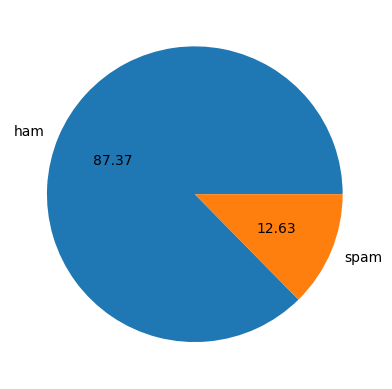

In [28]:
import matplotlib.pyplot as plt
plt.pie(data_set["target"].value_counts(),labels=["ham","spam"],autopct="%0.2f")
plt.show()
#

In [ ]:
#dta is imbalanced


In [29]:
import nltk

In [30]:
nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [34]:
data_set["num_characters"]=data_set["text"].apply(len)#numberof characters


In [35]:
data_set.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [37]:
#num of words
nltk.download('punkt_tab', quiet=True)
data_set["nums_words"]=data_set["text"].apply(lambda x:len(nltk.word_tokenize(x)))

In [38]:
data_set.head()

,target,text,num_characters,nums_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [39]:
#nums_sentences
data_set["num_sentences"]=data_set["text"].apply(lambda x:len(nltk.sent_tokenize(x)))

In [40]:
data_set.head()

,target,text,num_characters,nums_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [43]:
data_set[["num_characters","nums_words","num_sentences"]].describe()


,num_characters,nums_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [45]:
#HAM
data_set[data_set["target"]==0][["num_characters","nums_words","num_sentences"]].describe()

,num_characters,nums_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [46]:
#spam
data_set[data_set["target"]==1][["num_characters","nums_words","num_sentences"]].describe()

,num_characters,nums_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [47]:
import seaborn as sns


<Axes: xlabel='num_characters', ylabel='Count'>

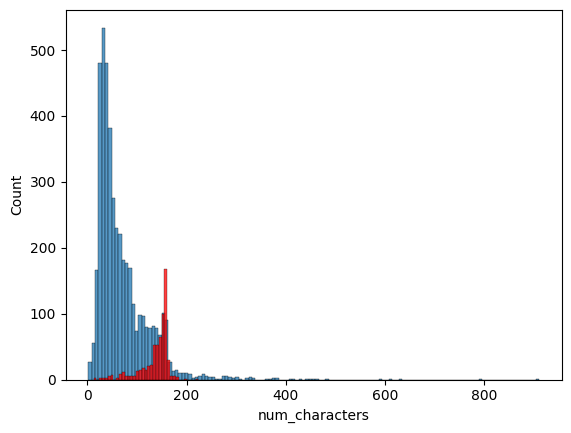

In [51]:
sns.histplot(data_set[data_set["target"]==0]["num_characters"])
sns.histplot(data_set[data_set["target"]==1]["num_characters"],color="red")

<Axes: xlabel='nums_words', ylabel='Count'>

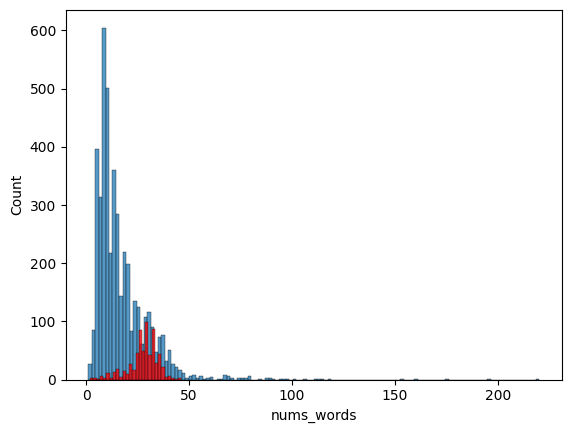

In [52]:
sns.histplot(data_set[data_set["target"]==0]["nums_words"])
sns.histplot(data_set[data_set["target"]==1]["nums_words"],color="red")

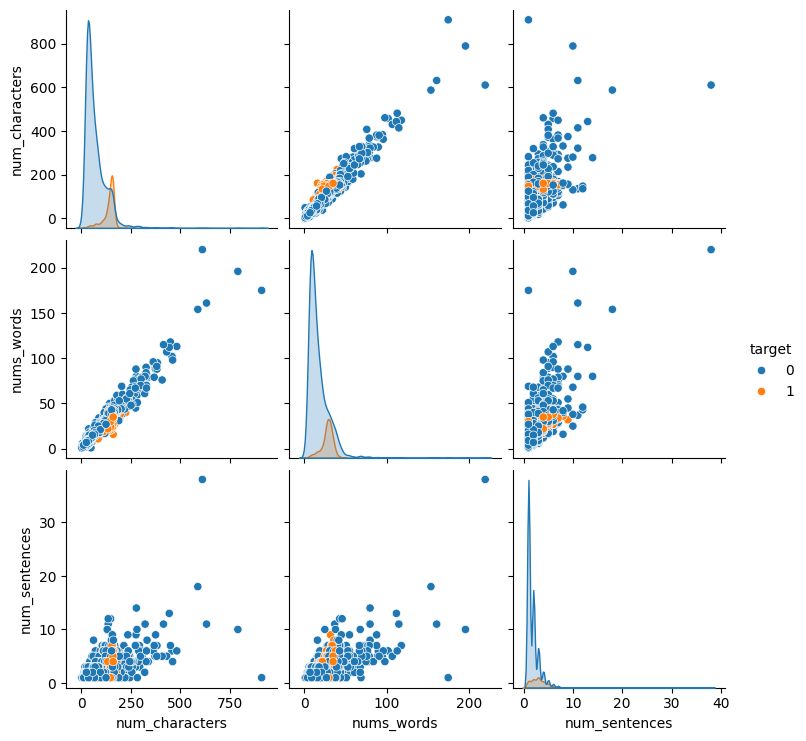

In [53]:
sns.pairplot(data_set,hue="target")

<Axes: >

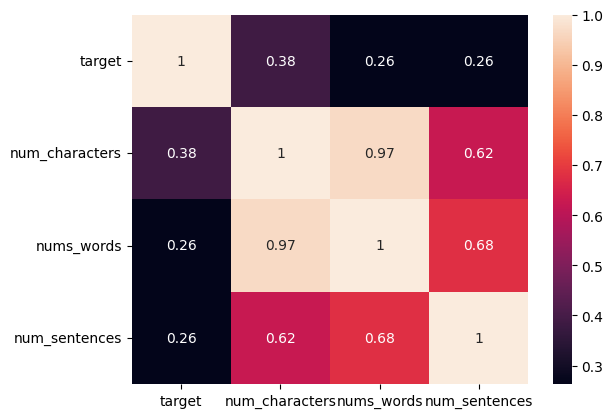

In [58]:
sns.heatmap(data_set.drop(columns=['text']).corr(),annot=True)

**3 DATA PREPROCESSING**


*   lower case
*   Tokenization


*   removing specail characters
*   removing stop words and punctuation


*   stemming
*   List item







In [89]:
def transfrom_text(text):
  text=text.lower()
  text=nltk.word_tokenize(text)
  y=[]
  for i in text:
    if(i.isalnum()):
      y.append(i)
  text=y[:]
  y.clear()
  for i in text:
    if(i not in stopwords.words("english") and i not in string.punctuation):
      y.append(i)
  text=y[:]
  y.clear()
  for i in text:
    y.append(ps.stem(i))
  return " ".join(y)

In [76]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords.words("english")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [77]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [95]:
transfrom_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [94]:
data_set["text"][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [86]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem("loving")

'love'

In [96]:
data_set["text"].apply(transfrom_text)

,text
0,go jurong point crazi avail bugi n great world...
1,ok lar joke wif u oni
2,free entri 2 wkli comp win fa cup final tkt 21...
3,u dun say earli hor u c alreadi say
4,nah think goe usf live around though
...,...
5567,2nd time tri 2 contact u pound prize 2 claim e...
5568,b go esplanad fr home
5569,piti mood suggest
5570,guy bitch act like interest buy someth els nex...


In [98]:
data_set["transformed_text"]=data_set["text"].apply(transfrom_text)

In [99]:
data_set.head()

,target,text,num_characters,nums_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [103]:
#word_cloud_of spam messages
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color="white")

In [105]:
spam_woc=wc.generate(data_set[data_set["target"]==1]["transformed_text"].str.cat(sep=" "))

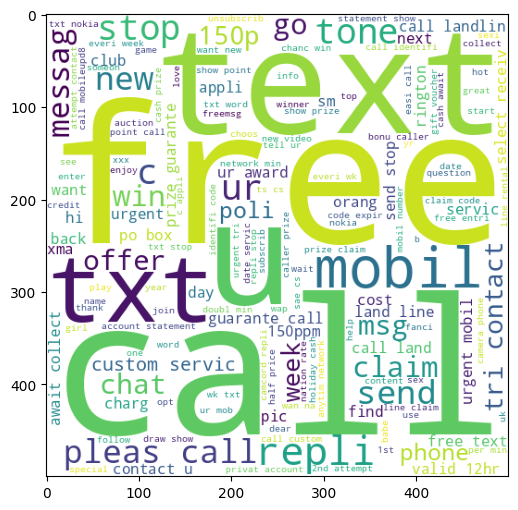

In [108]:
plt.figure(figsize=(15,6))
plt.imshow(spam_woc)

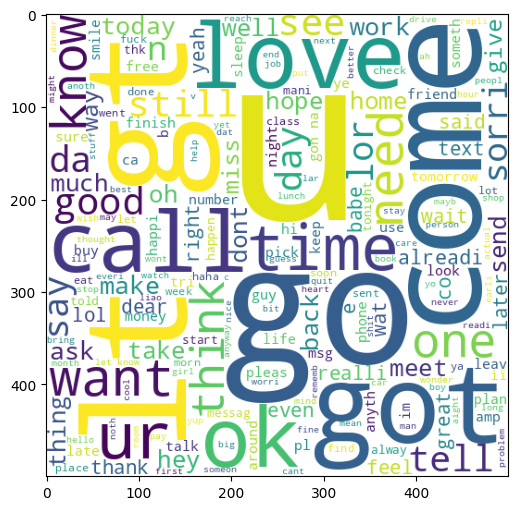

In [109]:
ham_woc=wc.generate(data_set[data_set["target"]==0]["transformed_text"].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ham_woc)

In [110]:
data_set.head()

,target,text,num_characters,nums_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [131]:
spam_corpus=[]
for msg in data_set[data_set["target"]==1]["transformed_text"].tolist():
  for words in msg.split():
    spam_corpus.append(words)

In [132]:
len(spam_corpus)

9939

In [133]:
from collections import Counter
Counter(spam_corpus).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

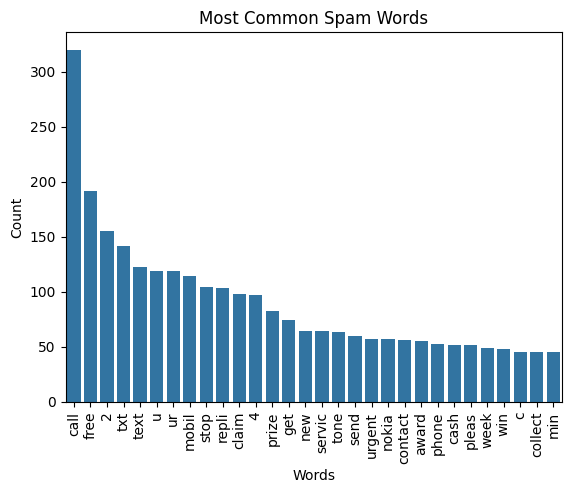

In [134]:
from collections import Counter
import matplotlib.pyplot as plt

# Get the 30 most common words and put them into a DataFrame
common_spam_words = pd.DataFrame(Counter(spam_corpus).most_common(30))

# Create the bar plot using keyword arguments for x and y
sns.barplot(x=common_spam_words[0], y=common_spam_words[1])
plt.xticks(rotation='vertical')
plt.title('Most Common Spam Words')
plt.xlabel('Words')
plt.ylabel('Count')
plt.show()

In [135]:
ham_corpus=[]
for msg in data_set[data_set["target"]==0]["transformed_text"].tolist():
  for words in msg.split():
    ham_corpus.append(words)

In [136]:
len(ham_corpus)


35404

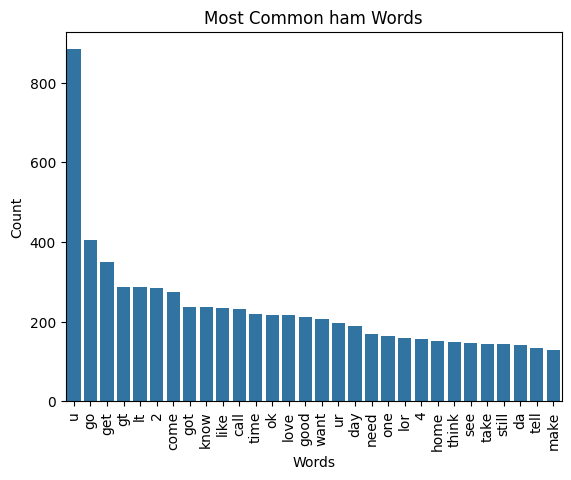

In [138]:
from collections import Counter
import matplotlib.pyplot as plt

# Get the 30 most common words and put them into a DataFrame
common_ham_words = pd.DataFrame(Counter(ham_corpus).most_common(30))

# Create the bar plot using keyword arguments for x and y
sns.barplot(x=common_ham_words[0], y=common_ham_words[1])
plt.xticks(rotation='vertical')
plt.title('Most Common ham Words')
plt.xlabel('Words')
plt.ylabel('Count')
plt.show()

**MODEL BUILDING**


In [229]:
#naive bayes algorithm
#converting text to vectors
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cd=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [230]:
X=tfidf.fit_transform(data_set["transformed_text"]).toarray()

In [195]:
#from sklearn.preprocessing import MinMaxScaler
#scaler=MinMaxScaler()#
#X=scaler.fit_transform(X)

In [231]:
X.shape

(5169, 3000)

In [232]:
y=data_set["target"].values

In [233]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [234]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=2,test_size=0.2)

In [235]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [236]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [237]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))


0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [238]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [239]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [ ]:
#tfidf && mnb

In [240]:
import pickle
pickle.dump(tfidf,open("vectorizer.pkl","wb"))
pickle.dump(mnb,open("model.pkl","wb"))
